# 📚 Predictive Analysis of Cancer
---
This project explores the Breast Cancer Wisconsin Dataset with the goal of classifying tumors as benign or malignant. Exploratory analyses and tests were performed using four machine learning models — Logistic Regression, Random Forest, Gradient Boosting, and KNN — to identify the best predictive approach.


https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data


## 1. 🟦 Load Data


---




### 1.1. 📗 Library Imports


In [ ]:
!pip install pyreaddbc --upgrade -q
!pip install dbfread -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
# Exploratory Analysis
from scipy.stats import ttest_ind
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [ ]:
# Modeling setup
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

import shap



### 1.2. 📗 Read File


In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/bschoola/FIAP-Pos-AI/refs/heads/main/Data/data.csv', encoding="utf-8-sig")

### 1.3. 📗 Are there null values and are variables 100% filled?


In [ ]:
missing = pd.DataFrame({
    "missing": df.isnull().sum(),
    "percentage": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["missing"] > 0].sort_values("percentage", ascending=False)
print(missing)


             faltantes  percentual
Unnamed: 32        569      100.00


### 1.4. 📗 Translate columns to Portuguese


In [ ]:
# rename fields
renomear = {
    "diagnosis": "diagnostico",
    "radius_mean": "raio_medio",
    "texture_mean": "textura_media",
    "perimeter_mean": "perimetro_medio",
    "area_mean": "area_media",
    "smoothness_mean": "suavidade_media",
    "compactness_mean": "compacidade_media",
    "concavity_mean": "concavidade_media",
    "concave points_mean": "pontos_concavos_media",
    "symmetry_mean": "simetria_media",
    "fractal_dimension_mean": "dimensao_fractal_media",
    "radius_se": "raio_erro_padrao",
    "texture_se": "textura_erro_padrao",
    "perimeter_se": "perimetro_erro_padrao",
    "area_se": "area_erro_padrao",
    "smoothness_se": "suavidade_erro_padrao",
    "compactness_se": "compacidade_erro_padrao",
    "concavity_se": "concavidade_erro_padrao",
    "concave points_se": "pontos_concavos_erro_padrao",
    "symmetry_se": "simetria_erro_padrao",
    "fractal_dimension_se": "dimensao_fractal_erro_padrao",
    "radius_worst": "raio_pior",
    "texture_worst": "textura_pior",
    "perimeter_worst": "perimetro_pior",
    "area_worst": "area_pior",
    "smoothness_worst": "suavidade_pior",
    "compactness_worst": "compacidade_pior",
    "concavity_worst": "concavidade_pior",
    "concave points_worst": "pontos_concavos_pior",
    "symmetry_worst": "simetria_pior",
    "fractal_dimension_worst": "dimensao_fractal_pior"
}

df = df.rename(columns=renomear)

## 2. 🟦 Exploratory Data Analysis (EDA)
---



### 📑🔎 2.1 General Analysis


#### 📊🧠 2.1.1. How many samples are there?



In [ ]:
linhas, colunas = df.shape

print(f"Total samples: {linhas}")


Total de amostras: 569


#### 📊🧠 2.1.2. How many features are there?




In [ ]:
print(f"Total features: {colunas}")

print("\nColumn names:")
print(df.columns.tolist())


Total de features: 33

Nomes das colunas:
['id', 'diagnostico', 'raio_medio', 'textura_media', 'perimetro_medio', 'area_media', 'suavidade_media', 'compacidade_media', 'concavidade_media', 'pontos_concavos_media', 'simetria_media', 'dimensao_fractal_media', 'raio_erro_padrao', 'textura_erro_padrao', 'perimetro_erro_padrao', 'area_erro_padrao', 'suavidade_erro_padrao', 'compacidade_erro_padrao', 'concavidade_erro_padrao', 'pontos_concavos_erro_padrao', 'simetria_erro_padrao', 'dimensao_fractal_erro_padrao', 'raio_pior', 'textura_pior', 'perimetro_pior', 'area_pior', 'suavidade_pior', 'compacidade_pior', 'concavidade_pior', 'pontos_concavos_pior', 'simetria_pior', 'dimensao_fractal_pior', 'Unnamed: 32']


#### 📊🧠 2.1.3. Are there irrelevant columns?



In [ ]:
display(df.describe())

,id,raio_medio,textura_media,perimetro_medio,area_media,suavidade_media,compacidade_media,concavidade_media,pontos_concavos_media,simetria_media,...,textura_pior,perimetro_pior,area_pior,suavidade_pior,compacidade_pior,concavidade_pior,pontos_concavos_pior,simetria_pior,dimensao_fractal_pior,Unnamed: 32
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,0.00
mean,30371831.43,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,NaN
std,125020585.61,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,NaN
min,8670.00,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,NaN
25%,869218.00,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,NaN
50%,906024.00,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,NaN
75%,8813129.00,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,NaN
max,911320502.00,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,NaN


In [ ]:
# The Unnamed feature is completely empty, so we will remove it.

df = df.drop(columns=["Unnamed: 32"], errors='ignore')


#### 📊🧠 2.1.4. Is the dataset balanced?




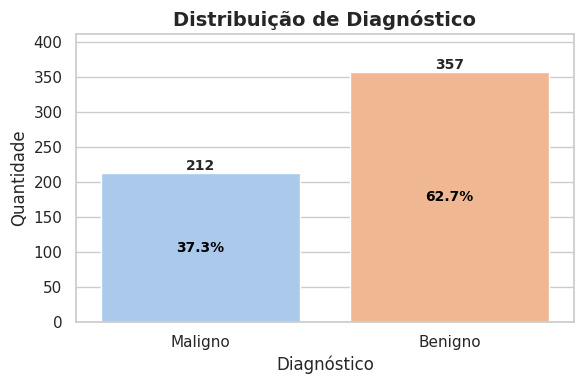

In [ ]:

# Map the values
y = df.diagnostico

y_plot = y.map({ 'B': 'Benign', 'M': 'Malignant'})

sns.set(style="whitegrid")
plt.figure(figsize=(6,4))

ax = sns.countplot(x=y_plot, hue=y_plot, palette="pastel", legend=False)

plt.title("Diagnosis Distribution", fontsize=14, weight='bold')
plt.xlabel("Diagnosis")
plt.ylabel("Count")

total = len(y_plot)

for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total

    # 📊 Percentage INSIDE the bar
    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center',
                fontsize=10, color='black', weight='bold')

    # 🔢 Count ABOVE the bar
    ax.annotate(f'{count}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, weight='bold')

# Avoids clipping the top number
ax.set_ylim(0, max(y_plot.value_counts()) * 1.15)

plt.tight_layout()
plt.show()


✅ Analysis: There is a slight imbalance toward benign. Given the values, we will test some different models and, if they do not perform well, we will consider using a class weight adjustment technique.


#### 📊🧠 2.1.5. What are the data types?


In [ ]:
print(df.dtypes)

id                                int64
diagnostico                      object
raio_medio                      float64
textura_media                   float64
perimetro_medio                 float64
area_media                      float64
suavidade_media                 float64
compacidade_media               float64
concavidade_media               float64
pontos_concavos_media           float64
simetria_media                  float64
dimensao_fractal_media          float64
raio_erro_padrao                float64
textura_erro_padrao             float64
perimetro_erro_padrao           float64
area_erro_padrao                float64
suavidade_erro_padrao           float64
compacidade_erro_padrao         float64
concavidade_erro_padrao         float64
pontos_concavos_erro_padrao     float64
simetria_erro_padrao            float64
dimensao_fractal_erro_padrao    float64
raio_pior                       float64
textura_pior                    float64
perimetro_pior                  float64


### 📑🔎 2.2. Univariate Analysis




#### 📊🧠 2.2.1. What does the analysis look like for the mean variables?


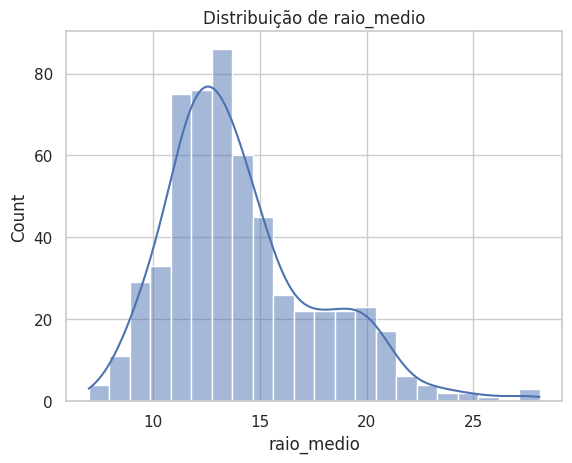

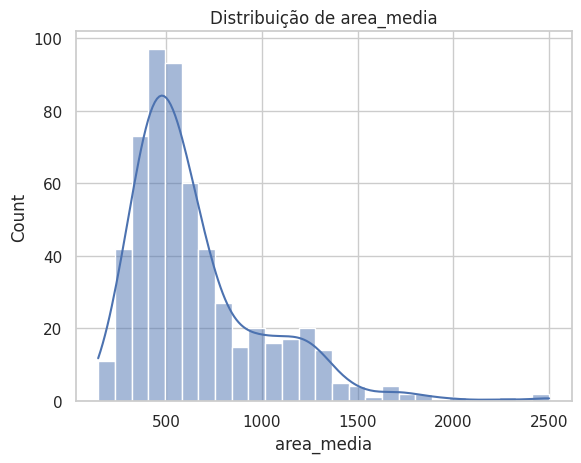

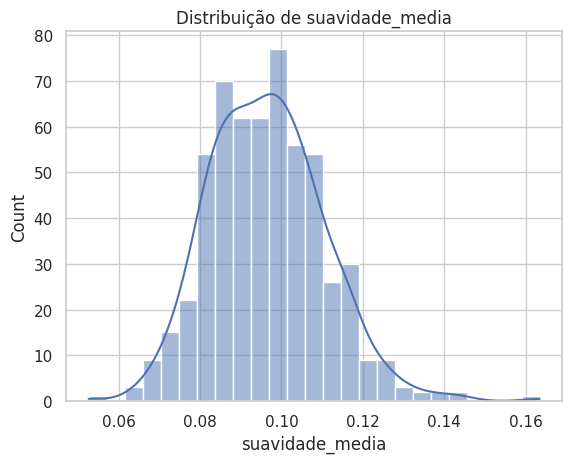

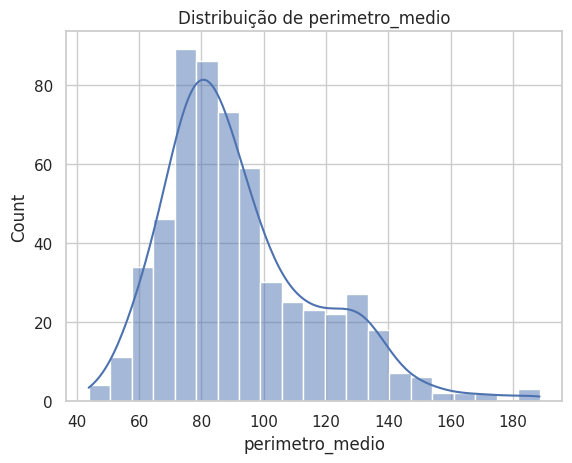

In [ ]:
colunas = ["raio_medio", "area_media", "suavidade_media", "perimetro_medio"]

for col in colunas:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


✅ Chart analysis:
- `raio_medio`: slightly right-skewed distribution
- `area_media`: high variability and presence of outliers
- `suavidade_media`: concentrated values with low variation
- `perimetro_medio`: also right-skewed


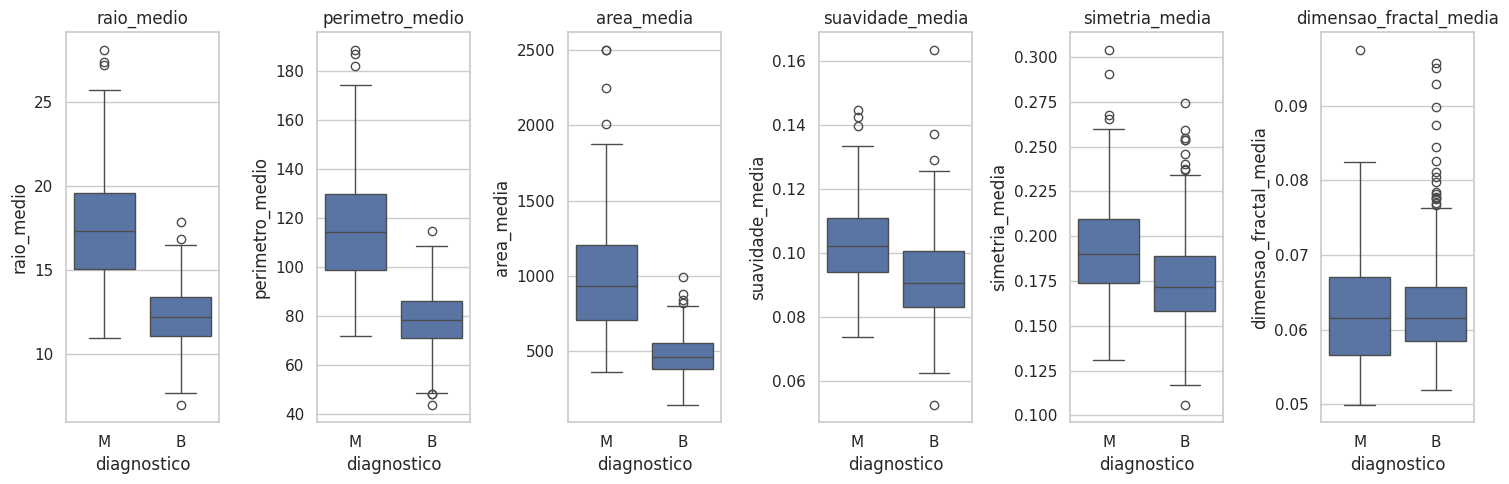

In [ ]:
# Analysis of mean fields based on diagnosis

# column list
colunas = ["raio_medio", "perimetro_medio", "area_media", "suavidade_media" , "simetria_media", "dimensao_fractal_media"]

# create subplots
plt.figure(figsize=(15, 5))

for i, col in enumerate(colunas, 1):
    plt.subplot(1, 6, i)
    sns.boxplot(x="diagnostico", y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()




✅ Analysis: We observed that malignant diagnoses have, in most cases, a higher median than benign ones — except for fractal dimension, which shows no significant variation.

Therefore, we believe the variables raio_medio, perimetro_medio, and area_media will be most relevant for the model.





#### 📊🧠 2.2.2. Are malignant tumors larger?



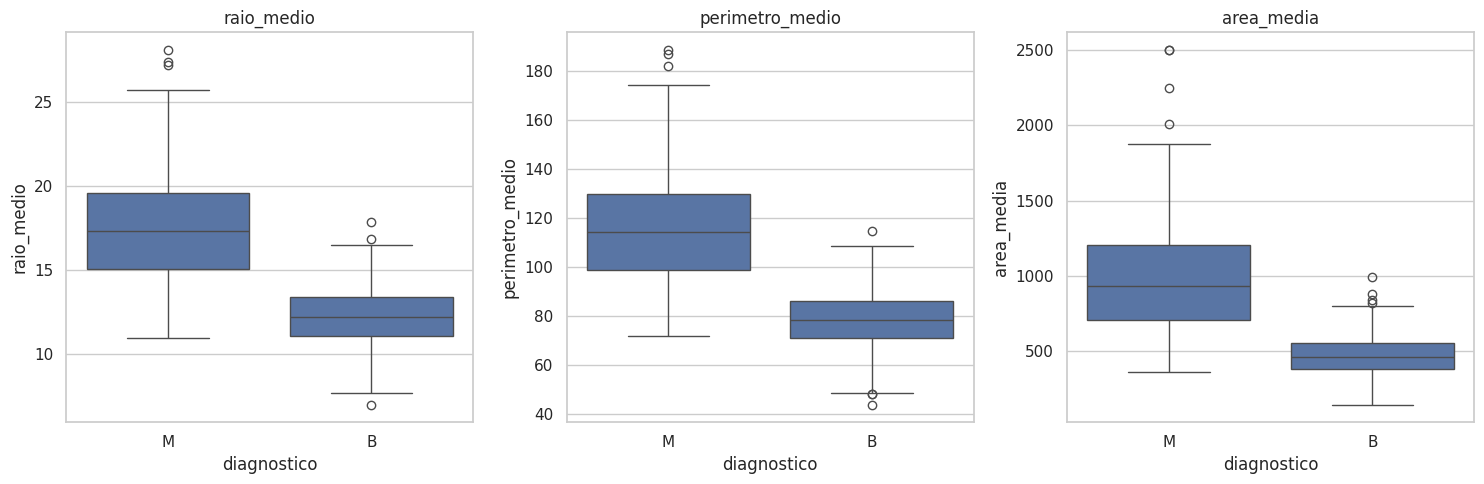

In [ ]:
colunas = ["raio_medio", "perimetro_medio", "area_media"]

plt.figure(figsize=(15,5))

for i, col in enumerate(colunas, 1):
    plt.subplot(1,3,i)
    sns.boxplot(x="diagnostico", y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

✅ Answer: Not all of them, but the majority are larger and generally show higher values for radius, perimeter, and area, as well as greater variability.

Size is an important characteristic in distinguishing between diagnoses.


#### 📊🧠 2.2.3. Which variables show the highest variability?



In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)
variabilidade = df.std(numeric_only=True).sort_values(ascending=False)

variabilidade.head(10)

,0
id,125020585.6122
area_pior,569.3570
area_media,351.9141
area_erro_padrao,45.4910
perimetro_pior,33.6025
perimetro_medio,24.2990
textura_pior,6.1463
raio_pior,4.8332
textura_media,4.3010
raio_medio,3.5240


In [ ]:
pd.reset_option('display.float_format')

✅ Answer: The variables with the highest variability are:
- `area`
- `perimeter`
- `texture`
- `radius`

Most variables are related to tumor size, except for `texture`.


#### 📊🧠 2.2.4. Do standard error variables differentiate diagnoses?



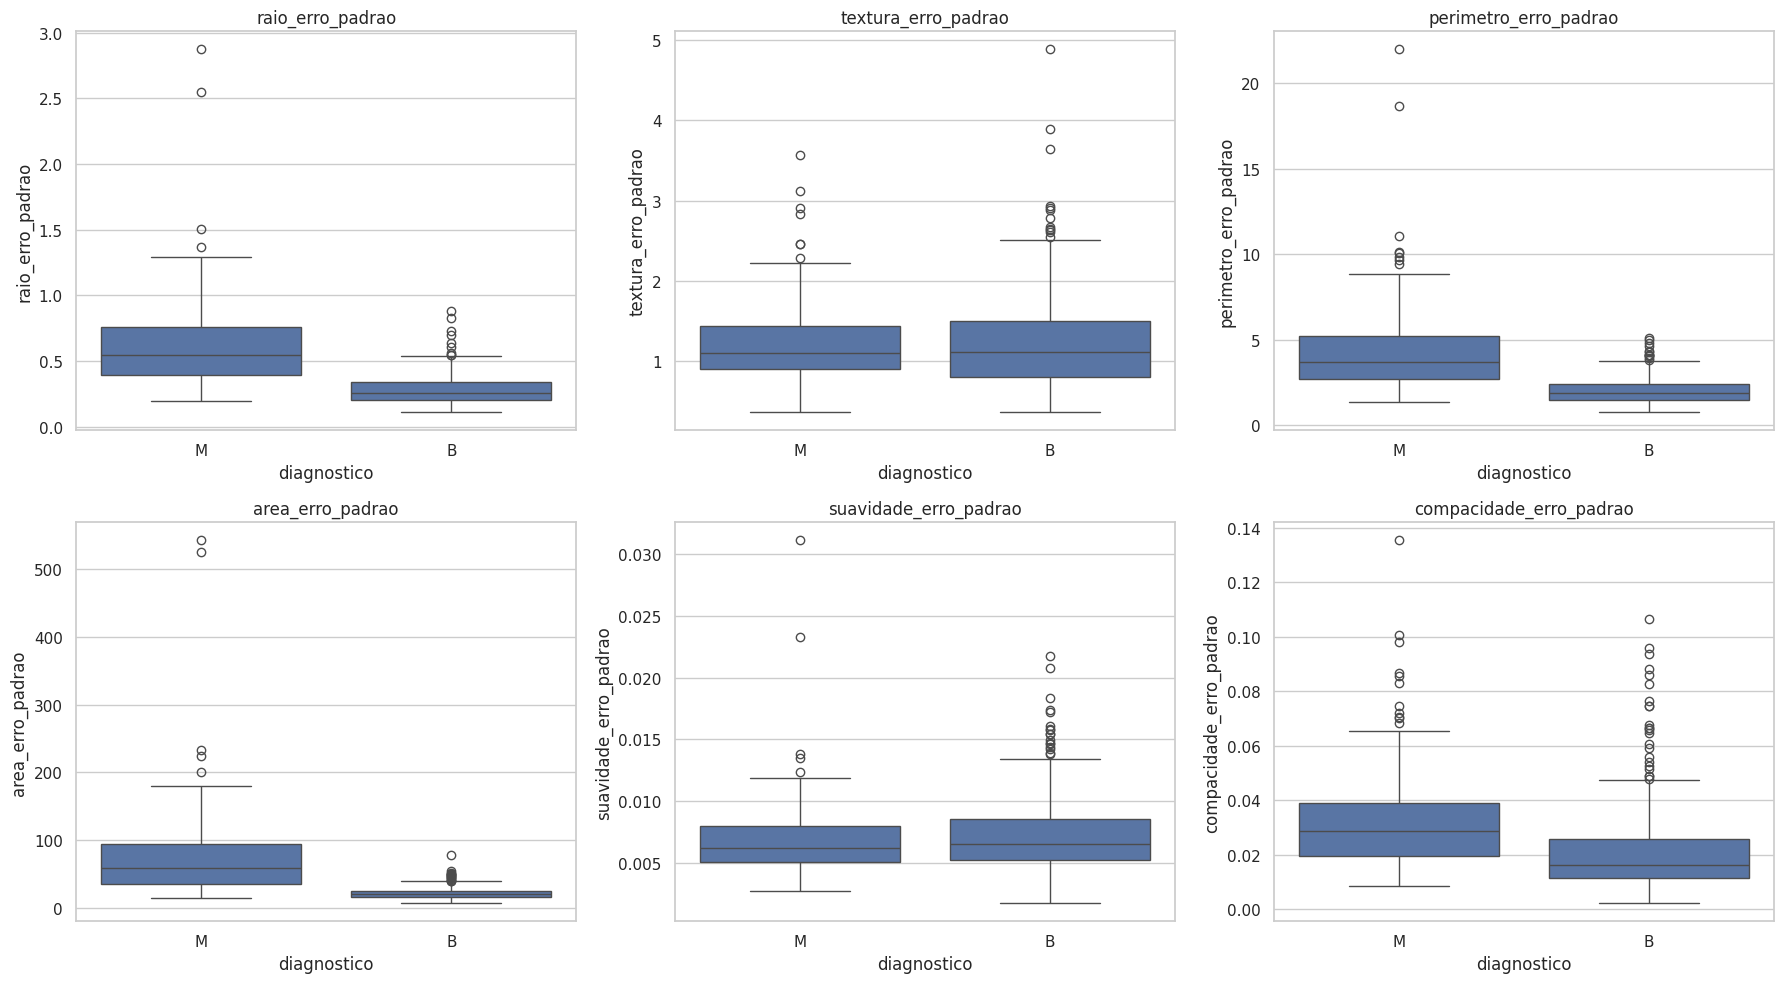

In [ ]:
colunas_se = [col for col in df.columns if "_erro_padrao" in col]

plt.figure(figsize=(18,10))

for i, col in enumerate(colunas_se[:6], 1):
    plt.subplot(2,3,i)
    sns.boxplot(x="diagnostico", y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()


✅ Analysis: Standard error variables tend to be larger in malignant tumors, indicating greater measurement irregularity.

We noticed that the smoothness standard error does not seem to be very relevant.


#### 📊🧠 2.2.5. What can we observe looking at the standard errors?



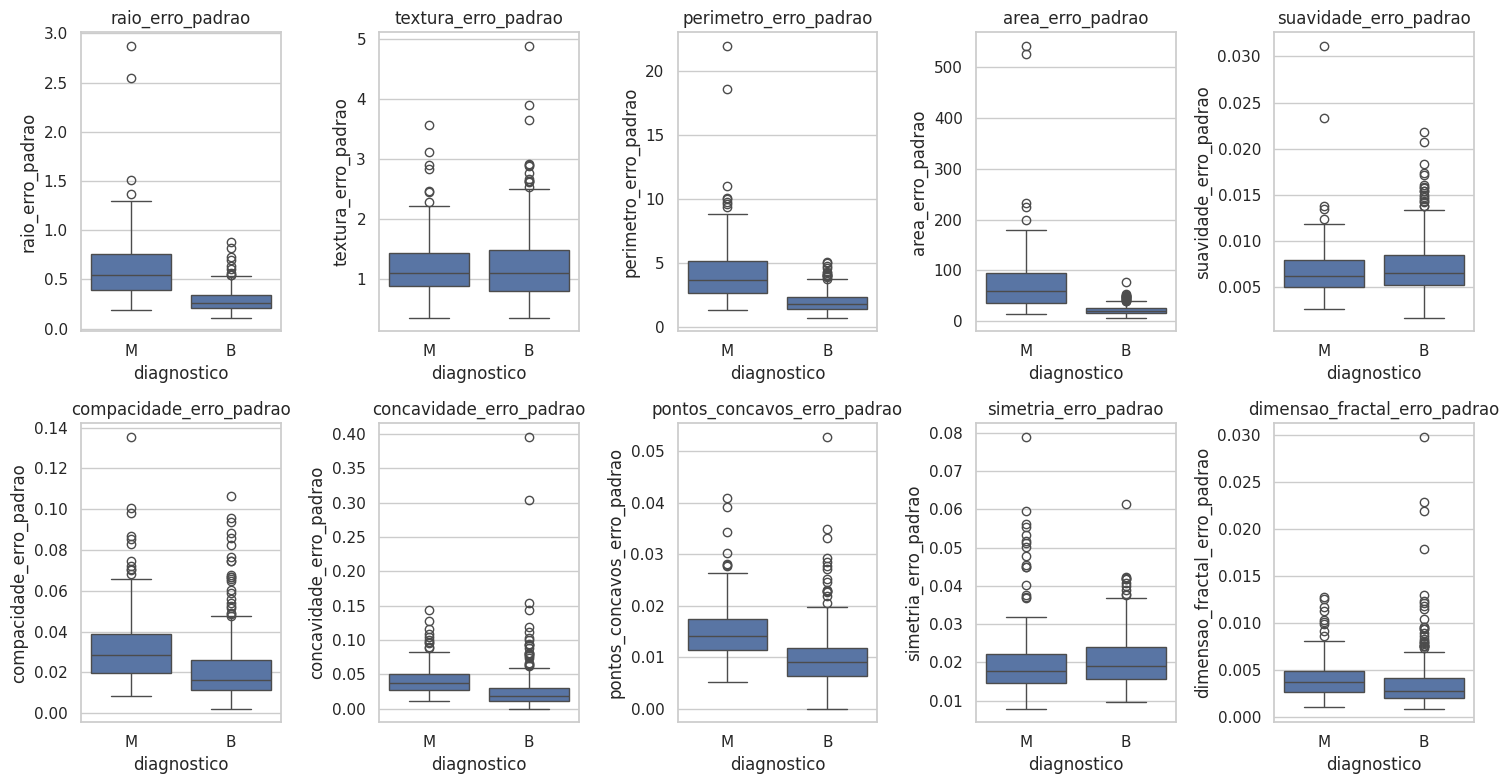

In [ ]:
# Analysis of mean fields based on diagnosis
colunas_se = [
    "raio_erro_padrao",
    "textura_erro_padrao",
    "perimetro_erro_padrao",
    "area_erro_padrao",
    "suavidade_erro_padrao",
    "compacidade_erro_padrao",
    "concavidade_erro_padrao",
    "pontos_concavos_erro_padrao",
    "simetria_erro_padrao",
    "dimensao_fractal_erro_padrao"
]

# create subplots
plt.figure(figsize=(15, 8))

for i, col in enumerate(colunas_se, 1):
    plt.subplot(2, 5, i)
    sns.boxplot(x="diagnostico", y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()



✅ Analysis: Standard error is a variation variable. In our case, with most values close to zero and little variation between classes, we understand that when there is no significant difference between malignant and benign, these variables would not help with classification.

We also observed that values are more concentrated, with a slight shift toward higher values in malignant cases.


#### 📊🧠 2.2.6. Is there correlation between variables?


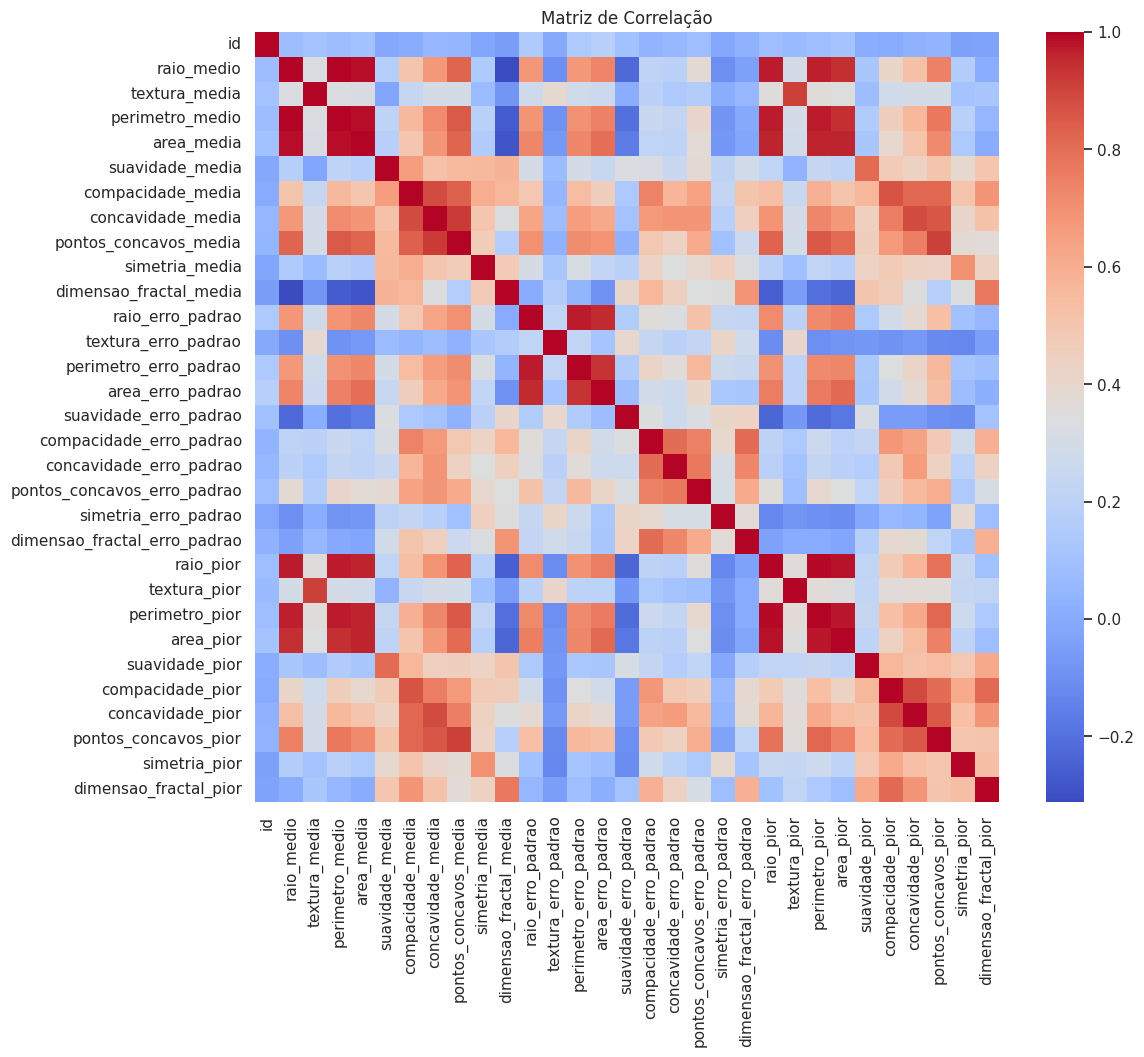

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


✅ Analysis: Strong correlation exists between:

*   `radius`, `perimeter`, and `area` from the mean group with the worst group.
*   We also observed strong correlation among `concavidade_pior`, `compacidade_pior`, and `pontos_concavos_pior`.
*   The same applies to `raio_medio`, `textura_media`, and `perimetro_medio`.

This indicates redundancy among these variables.





#### 🟦 Conclusion

The univariate analysis showed that:

- Malignant tumors tend to be larger
- They show greater variability
- They have greater structural irregularity
- Size variables are highly relevant
- There are redundant variables


### 📑🔎 2.3. Bivariate Analysis


#### 📊🧠 2.3.1. Which variables best differentiate benign and malignant tumors?


In [ ]:

df_bi = df.copy()

# create numeric version of target WITHOUT altering the original df
df_bi["diagnostico_binario"] = df_bi["diagnostico"].map({"M": 1, "B": 0})

features = [col for col in df_bi.columns if col not in ["diagnostico", "diagnostico_binario"]]

mean_by_class = df_bi.groupby("diagnostico_binario")[features].mean().T

mean_by_class["diferenca_percentual"] = (
    (mean_by_class[1] - mean_by_class[0]) / mean_by_class[0]
) * 100

mean_by_class = mean_by_class.sort_values("diferenca_percentual", ascending=False)

pd.set_option('display.float_format', '{:.2f}'.format)

mean_by_class.head(10)


diagnostico_binario,0,1,diferenca_percentual
concavidade_media,0.05,0.16,249.07
area_erro_padrao,21.14,72.67,243.85
pontos_concavos_media,0.03,0.09,242.14
concavidade_pior,0.17,0.45,171.06
area_pior,558.90,1422.29,154.48
pontos_concavos_pior,0.07,0.18,144.80
perimetro_erro_padrao,2.00,4.32,116.16
raio_erro_padrao,0.28,0.61,114.40
area_media,462.79,978.38,111.41
compacidade_pior,0.18,0.37,105.19


✅ Analysis: The higher the `diferenca_percentual` variable, the stronger the separation between class means. We can see that `concavidade_media`, `area_erro_padrao`, and `pontos_concavos_media` show strong class separation.


#### 📊🧠 2.3.2. Which variables have the highest linear correlation with the diagnosis?


In [ ]:
corr = df_bi.corr(numeric_only=True)

corr_target = corr["diagnostico_binario"].drop("diagnostico_binario").sort_values(ascending=False)

corr_target.head(50)


,diagnostico_binario
pontos_concavos_pior,0.79
perimetro_pior,0.78
pontos_concavos_media,0.78
raio_pior,0.78
perimetro_medio,0.74
area_pior,0.73
raio_medio,0.73
area_media,0.71
concavidade_media,0.70
concavidade_pior,0.66


✅ Analysis: We can see that strong linear correlation exists, so a simple logistic regression model may already solve our classification. No strong negative correlations were observed.

Given the high correlation, the feature set can be significantly reduced without performance loss.


#### 📊🧠 2.3.3. Are the differences between benign and malignant statistically significant?


In [ ]:

p_values = {}

for col in features:
    group_0 = df_bi[df_bi["diagnostico_binario"] == 0][col]
    group_1 = df_bi[df_bi["diagnostico_binario"] == 1][col]

    stat, p = ttest_ind(group_0, group_1)
    p_values[col] = p

p_values = pd.Series(p_values).sort_values()

p_values.head(30)


,0
pontos_concavos_pior,0.00
perimetro_pior,0.00
pontos_concavos_media,0.00
raio_pior,0.00
perimetro_medio,0.00
area_pior,0.00
raio_medio,0.00
area_media,0.00
concavidade_media,0.00
concavidade_pior,0.00


✅ Analysis: We can see that the dataset is highly separable, with values close to 0.
We also identified weak variables with values further from zero, such as `id`, `dimensao_fractal_media`, and `textura_erro_padrao`.

We also found borderline variables that are likely unstable: `dimensao_fractal_erro_padrao` and `suavidade_erro_padrao`,
which we will probably remove.


#### 📊🧠 2.3.4. Do two variables together improve separation?


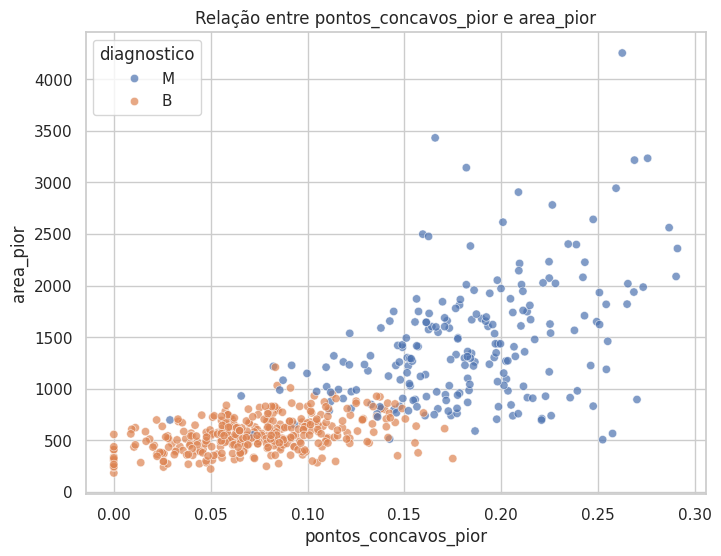

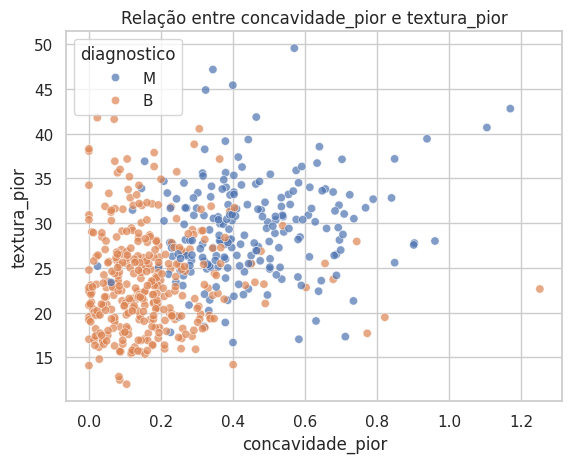

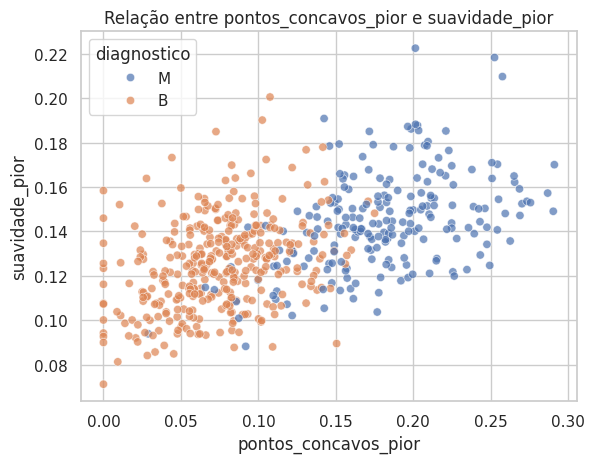

In [ ]:
top_features2 = [ 'pontos_concavos_pior', 'area_pior', 'concavidade_pior', 'textura_pior', 'suavidade_pior' ]


plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_bi,
    x=top_features2[0],
    y=top_features2[1],
    hue="diagnostico",
    alpha=0.7
)

plt.title(f"Relação entre {top_features2[0]} e {top_features2[1]}")
plt.show()

sns.scatterplot(
    data=df_bi,
    x=top_features2[2],
    y=top_features2[3],
    hue="diagnostico",
    alpha=0.7
)

plt.title(f"Relação entre {top_features2[2]} e {top_features2[3]}")
plt.show()

sns.scatterplot(
    data=df_bi,
    x=top_features2[0],
    y=top_features2[4],
    hue="diagnostico",
    alpha=0.7
)

plt.title(f"Relação entre {top_features2[0]} e {top_features2[4]}")
plt.show()



✅ Analysis: Combining two variables significantly improves class separation. It was more effective to use variables with different information (not highly correlated with each other).



#### 📊🧠 2.3.5. Is there a set of variables that separates the problem well?


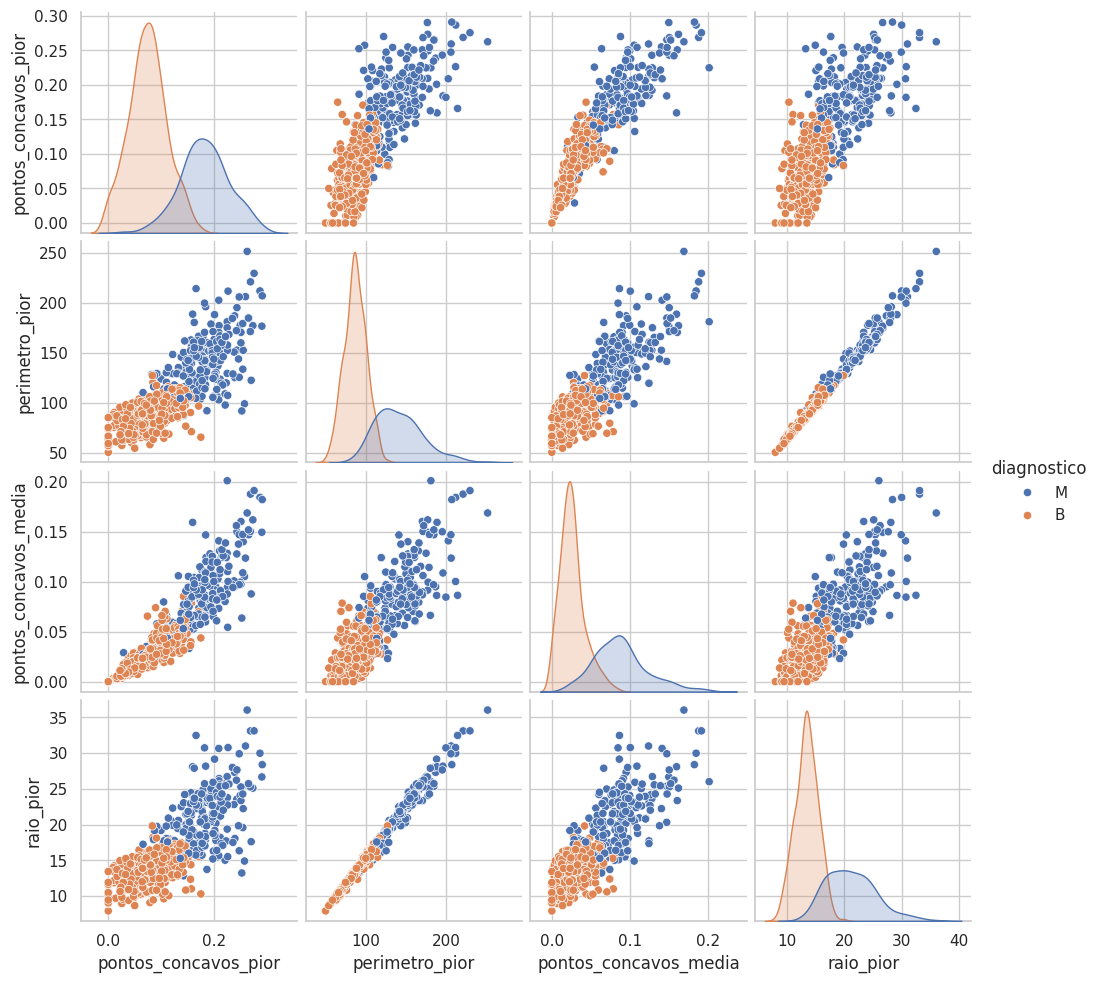

In [ ]:
top_features = corr_target.head(5).index

sns.pairplot(
    df_bi[list(top_features[:4]) + ["diagnostico"]],
    hue="diagnostico"
)

✅ Analysis: Patterns can be seen in almost all variables shown; some combinations can separate better than individual variables.


#### 🟦 Conclusion

In our analysis, the most important variables are:

- `area_pior`
- `perimetro_pior`
- `raio_pior`
- `pontos_concavos_pior`
- `concavidade_pior`
- `area_media`
- `perimetro_medio`
- `raio_medio`
- `pontos_concavos_media`
- `concavidade_media`

And there are redundant variables among them:

- `raio_*`
- `perimetro_*`
- `area_*`

We observed that the problem is easy to separate into classes, and some variables already help in the decision. We can choose `raio_pior`, `pontos_concavos_pior`, `concavidade_pior`, and `textura_pior` to build the model.


### 📑🔎 2.4. Multivariate Analysis


#### 📊🧠 2.4.1. Which variables are most important when considered simultaneously?


In [ ]:
# copy
df_bi = df.copy()

# binary target
df_bi['diagnostico_binario'] = df_bi['diagnostico'].map({'M': 1, 'B': 0})

# separate X and y
X = df_bi.drop(columns=['diagnostico', 'diagnostico_binario'])
y = df_bi['diagnostico_binario']

# model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# importance
importancias = pd.Series(model.feature_importances_, index=X.columns)

# sort
importancias.sort_values(ascending=False).head(15)


,0
area_pior,0.13
raio_pior,0.13
pontos_concavos_pior,0.12
perimetro_pior,0.11
pontos_concavos_media,0.10
perimetro_medio,0.05
concavidade_pior,0.05
concavidade_media,0.05
area_media,0.05
area_erro_padrao,0.04


✅ Analysis: Here we see that the most important features are:

- `area_pior`
- `raio_pior`
- `pontos_concavos_pior`
- `perimetro_pior`

We chose to use only `area_pior` to represent the size-related variables.


#### 📊🧠 2.4.2. Do we lose performance by reducing the number of variables?


In [ ]:
selected_features = [ 'area_pior', 'textura_pior', 'pontos_concavos_pior', 'concavidade_pior' ]

# model
model = RandomForestClassifier(random_state=42)

# score with all variables
score_full = cross_val_score(model, X, y, cv=5).mean()

# score with selected variables
X_reduzido = X[selected_features]
score_reduzido = cross_val_score(model, X_reduzido, y, cv=5).mean()

score_full, score_reduzido


(np.float64(0.9578481602235678), np.float64(0.9543393882937432))

✅ Analysis: Keeping only the features:

`area_pior`

`textura_pior`

`pontos_concavos_pior`

`concavidade_pior`

Both scores remained very close. We successfully eliminated noise and mitigated risk without making the model heavier. If the scores had been very different, we would have excluded important information.


#### 📊🧠 2.4.3. Are the classes separable when we combine variables?


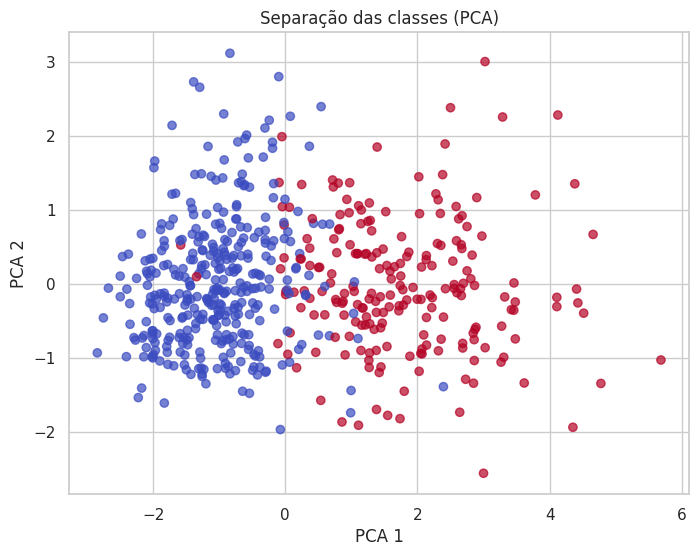

In [ ]:

X = df_bi[selected_features]
y = df_bi['diagnostico_binario']


# 🔥 standardization (ESSENTIAL for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# reduce to 2 components
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

# plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Class Separation (PCA)')
plt.show()


✅ Analysis: There was some overlap but a clear separation was achieved, confirming that the problem is easily classifiable.


#### 🟦 Conclusion

Redundancy groups:

- `radius`, `perimeter`, `area`
- `_medio` and `_pior` groups

Non-important variables:

- `*_erro_padrao`
- `simetria_*` and `dimensao_fractal_*`


Therefore, the recommended variables are:

- `area_pior`
- `textura_pior`
- `pontos_concavos_pior`
- `concavidade_pior`



## 3. 🟦 Modeling
---



### 3.1. 💻 Modeling Setup


#### 3.1.1. 🧠 Train and Test Split


In [ ]:
# copy
df_bi = df.copy()

# binary target
df_bi['diagnostico_binario'] = df_bi['diagnostico'].map({'M': 1, 'B': 0})

selected_features = [ 'area_pior', 'textura_pior', 'pontos_concavos_pior', 'concavidade_pior' ]

# 🔥 keep only the necessary columns
df_modelo = df_bi[selected_features + ['diagnostico_binario']].copy()

# separate X and y
X = df_modelo[selected_features]
y = df_modelo['diagnostico_binario']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### 3.2. 🚀 Modeling


#### 3.2.2. 🧠 Model - Logistic Regression


In [ ]:
# pipeline with normalization
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

# training
pipe_lr.fit(X_train, y_train)

# prediction
y_pred = pipe_lr.predict(X_test)
y_prob = pipe_lr.predict_proba(X_test)[:,1]

# metrics
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("F1-score:", f1_score(y_test, y_pred))


Logistic Regression
Accuracy: 0.956140350877193
Precision: 0.9743589743589743
Recall: 0.9047619047619048
ROC-AUC: 0.998015873015873
F1-score: 0.9382716049382716


#### 3.2.3. 🧠 Model - Random Forest


In [ ]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
y_prob = model_rf.predict_proba(X_test)[:,1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("F1-score:", f1_score(y_test, y_pred))


Random Forest
Accuracy: 0.9649122807017544
Precision: 0.975
Recall: 0.9285714285714286
ROC-AUC: 0.9953703703703703
F1-score: 0.9512195121951219


#### 3.2.4. 🧠 Model - Gradient Boosting (XGBoost or similar)


In [ ]:
model_gb = GradientBoostingClassifier(random_state=42)

model_gb.fit(X_train, y_train)

y_pred = model_gb.predict(X_test)
y_prob = model_gb.predict_proba(X_test)[:,1]

print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("F1-score:", f1_score(y_test, y_pred))


Gradient Boosting
Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9285714285714286
ROC-AUC: 0.9933862433862434
F1-score: 0.9629629629629629


#### 3.2.5. 🧠 Model - KNN (K Neighbors Classifier)


In [ ]:

# pipeline (ESSENTIAL to normalize for KNN)
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

# training
pipe_knn.fit(X_train, y_train)

# prediction
y_pred = pipe_knn.predict(X_test)
y_prob = pipe_knn.predict_proba(X_test)[:,1]

# metrics
print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("F1-score:", f1_score(y_test, y_pred))


KNN
Accuracy: 0.9473684210526315
Precision: 0.95
Recall: 0.9047619047619048
ROC-AUC: 0.9953703703703703
F1-score: 0.926829268292683


✅ Analysis: KNN does not use feature importance; instead, it determines classification based on the proximity to neighboring data points.


#### 3.2.6. 🧠 Cross-validation: Which model is most consistent and reliable?


In [ ]:
models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": model_rf,
    "Gradient Boosting": model_gb,
    "KNN": pipe_knn
}

scoring = {
    "recall": "recall",
    "f1": "f1"
}

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=10, scoring=scoring)

    recall_mean = scores["test_recall"].mean()
    f1_mean = scores["test_f1"].mean()

    print(f"{name}")
    print(f"  Mean Recall: {recall_mean:.4f}")
    print(f"  Mean F1-score: {f1_mean:.4f}")
    print("-" * 30)


Regressão logistica
  Recall médio: 0.9390
  F1-score médio: 0.9543
------------------------------
Random Forest
  Recall médio: 0.9390
  F1-score médio: 0.9363
------------------------------
Gradient Boosting
  Recall médio: 0.9344
  F1-score médio: 0.9337
------------------------------
KNN
  Recall médio: 0.9340
  F1-score médio: 0.9426
------------------------------


##### ✅ Analysis:

In our evaluation, a `False Negative` is a much more dangerous outcome for the patient, as it would prevent them from starting treatment as soon as possible. In this case, `Recall` would be the most appropriate metric.

However, in a hospital prediction system evaluated later by a doctor, the `F1-Score` could be more appropriate since it penalizes both precision and recall.

In both cases, `Logistic Regression` performed best in our analysis.

Legend:

*   Accuracy: How many predictions are correct overall.
*   Precision: Among those the model classified as malignant, how many were correct.
*   Recall: Among the actual malignant cases in the test set, how many were correctly identified.
*   F1-Score: The model is balanced between precision and recall.
*   ROC_AUC: How well our model separated malignant from benign.




##### 3.2.6.1. ❓ SHAP


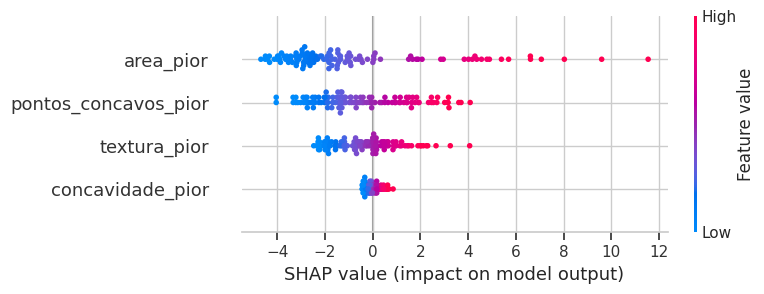

In [ ]:
scaler = pipe_lr.named_steps['scaler']
model = pipe_lr.named_steps['model']

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)


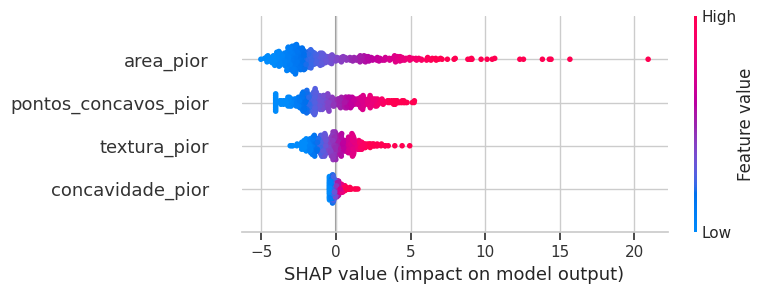

In [ ]:

# transform data with scaler
X_train_scaled = pipe_lr.named_steps['scaler'].transform(X_train)

# get internal model
model_lr = pipe_lr.named_steps['model']

# linear explainer
explainer_lr = shap.LinearExplainer(model_lr, X_train_scaled)

shap_values_lr = explainer_lr.shap_values(X_train_scaled)

# 🔥 VERY IMPORTANT: use X_train in the plot
shap.summary_plot(shap_values_lr, X_train)


✅ Analysis: The feature `area_pior` has the greatest impact on the model output.


###### 📖 SHAP -> Benign Case


In [ ]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_scaled[0],
    feature_names=X.columns
)


###### 📖 SHAP -> Malignant Case


In [ ]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[1],
    X_test_scaled[1],
    feature_names=X.columns
)

##### 3.2.6.2. ❓ Feature Importance: Which variables does the model use most to make decisions?


In [ ]:
# get coefficients
coef = pipe_lr.named_steps['model'].coef_[0]

# associate with features
coef_df = pd.DataFrame({
    'variable': X.columns,
    'coefficient': coef
}).sort_values(by='coefficient', ascending=False)

coef_df


,variavel,coeficiente
0,area_pior,3.71
2,pontos_concavos_pior,2.13
1,textura_pior,1.30
3,concavidade_pior,0.32
